# Surface-Potential PINN

In [1]:
# Import the shared surface-potential functions.
import torch
import matplotlib.pyplot as plt

from phis_init import phi_init
from physics_loss import physics_loss
from SurfacePotential import DeltaPhisPINN, surface_potential, save_surface_potential_pkl


## Parameters and collocation points

In [2]:
# Define the physical parameters and deterministic collocation grid.
device = torch.device("cpu")
dtype = torch.float64
torch.manual_seed(42)

T = 298.15

NA = 1.0e16
eps_sic = 9.26 * 8.854e-14
Cox = 7.0e-8
Vfbs0 = -1.0
Dit_mid = 2.0e11
Dit_edge = 2.0e13
sigma_it = 0.1
Eg = 3.26
Ec_minus_Ei = Eg / 2.0
Qox = 1.602e-7

VGS_MIN = -10.0
VGS_MAX = 30.0
PHIF_MIN = 0.0
PHIF_MAX = 20.0

N_VGS = 161
N_PHIF = 101

Vgs_axis = torch.linspace(
    VGS_MIN,
    VGS_MAX,
    N_VGS,
    dtype=dtype,
    device=device,
)

phi_f_axis = torch.linspace(
    PHIF_MIN,
    PHIF_MAX,
    N_PHIF,
    dtype=dtype,
    device=device,
)

Vgs_grid, phi_f_grid = torch.meshgrid(
    Vgs_axis,
    phi_f_axis,
    indexing="ij",
)

Vgs_train = Vgs_grid.reshape(-1, 1)
phi_f_train = phi_f_grid.reshape(-1, 1)

N_train = Vgs_train.shape[0]

Model = DeltaPhisPINN().to(
    device=device,
    dtype=dtype,
)

PKL_PATH = "phis_PINN.pkl"
PTH_PATH = "phis_PINN_surface.pth"

print("Training points =", N_train)
print(
    "Vgs range =",
    float(Vgs_train.min()),
    "to",
    float(Vgs_train.max()),
    "V",
)
print(
    "phi_f range =",
    float(phi_f_train.min()),
    "to",
    float(phi_f_train.max()),
    "V",
)
print("Temperature =", T, "K")

Training points = 16261
Vgs range = -10.0 to 30.0 V
phi_f range = 0.0 to 20.0 V
Temperature = 298.15 K


## Physics-informed training

In [3]:
# Train the PINN with early stopping.
MAX_EPOCHS = 3000
BATCH_SIZE = 1024
LEARNING_RATE = 1.0e-4
PATIENCE = 300
MIN_DELTA = 1.0e-7

optimizer = torch.optim.Adam(
    Model.parameters(),
    lr=LEARNING_RATE,
    foreach=False,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=100,
    min_lr=1.0e-6,
)

loss_history = []

best_loss = float("inf")
best_state = None
epochs_without_improvement = 0

for epoch in range(MAX_EPOCHS):

    permutation = torch.randperm(
        N_train,
        device=device,
    )

    epoch_loss = 0.0
    batch_count = 0

    Model.train()

    for start in range(
        0,
        N_train,
        BATCH_SIZE,
    ):

        idx = permutation[
            start:start + BATCH_SIZE
        ]

        Vgs_batch = Vgs_train[idx]
        phi_f_batch = phi_f_train[idx]

        optimizer.zero_grad(
            set_to_none=True
        )

        phis_PINN = surface_potential(
            Model,
            Vgs_batch,
            phi_f_batch,
            T=T,
            NA=NA,
            eps_sic=eps_sic,
            Cox=Cox,
            Vfbs0=Vfbs0,
            Dit_mid=Dit_mid,
            Dit_edge=Dit_edge,
            sigma_it=sigma_it,
            Eg=Eg,
        )

        loss = physics_loss(
            phis_PINN,
            Vgs_batch,
            phi_f_batch,
            T,
            NA,
            eps_sic,
            Cox,
            Vfbs0,
            Qox,
            Dit_mid,
            Dit_edge,
            sigma_it,
            Ec_minus_Ei,
            Eg,
        )

        if not torch.isfinite(loss):
            raise RuntimeError(
                f"Non-finite loss at epoch {epoch}"
            )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            Model.parameters(),
            max_norm=10.0,
        )

        optimizer.step()

        epoch_loss += loss.item()
        batch_count += 1

    epoch_loss /= batch_count

    loss_history.append(
        epoch_loss
    )

    scheduler.step(
        epoch_loss
    )

    if epoch_loss < best_loss - MIN_DELTA:

        best_loss = epoch_loss

        best_state = {
            key: value.detach()
            .cpu()
            .clone()
            for key, value
            in Model.state_dict().items()
        }

        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1

    if (
        epoch % 100 == 0
        or epoch == MAX_EPOCHS - 1
    ):

        current_lr = (
            optimizer.param_groups[0]["lr"]
        )

        print(
            f"Epoch {epoch:4d} | "
            f"L_SPE = {epoch_loss:.6e} | "
            f"best = {best_loss:.6e} | "
            f"lr = {current_lr:.2e}"
        )

    if epochs_without_improvement >= PATIENCE:

        print(
            f"Early stopping at epoch {epoch}"
        )

        break

Model.load_state_dict(
    best_state,
    strict=True,
)

Model.eval()

print(
    "Best PI-loss =",
    best_loss,
)

Epoch    0 | L_SPE = 1.782776e+01 | best = 1.782776e+01 | lr = 1.00e-04
Epoch  100 | L_SPE = 3.824914e-01 | best = 3.824914e-01 | lr = 1.00e-04
Epoch  200 | L_SPE = 1.633013e-01 | best = 1.633013e-01 | lr = 1.00e-04
Epoch  300 | L_SPE = 1.525007e-01 | best = 1.522602e-01 | lr = 1.00e-04
Epoch  400 | L_SPE = 1.450961e-01 | best = 1.449354e-01 | lr = 1.00e-04
Epoch  500 | L_SPE = 1.395691e-01 | best = 1.393424e-01 | lr = 1.00e-04
Epoch  600 | L_SPE = 1.347066e-01 | best = 1.341500e-01 | lr = 1.00e-04
Epoch  700 | L_SPE = 1.285679e-01 | best = 1.285679e-01 | lr = 1.00e-04
Epoch  800 | L_SPE = 1.241125e-01 | best = 1.227290e-01 | lr = 1.00e-04
Epoch  900 | L_SPE = 1.164205e-01 | best = 1.163514e-01 | lr = 1.00e-04
Epoch 1000 | L_SPE = 1.098798e-01 | best = 1.098798e-01 | lr = 1.00e-04
Epoch 1100 | L_SPE = 1.037542e-01 | best = 1.033969e-01 | lr = 1.00e-04
Epoch 1200 | L_SPE = 9.759611e-02 | best = 9.759209e-02 | lr = 1.00e-04
Epoch 1300 | L_SPE = 9.222892e-02 | best = 9.206722e-02 | lr = 1

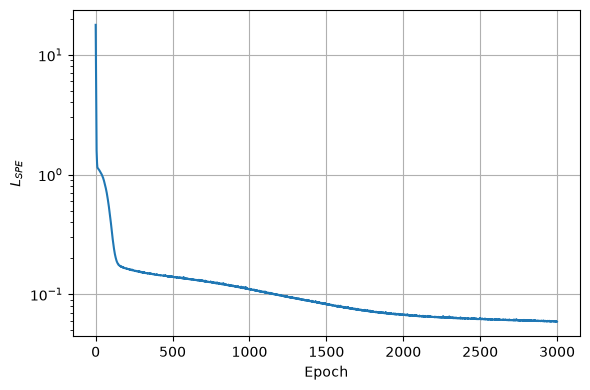

In [4]:
# Plot the PINN training loss.
plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel(r"$L_{SPE}$")
plt.grid(True)
plt.tight_layout()
plt.show()


## Surface-potential curves

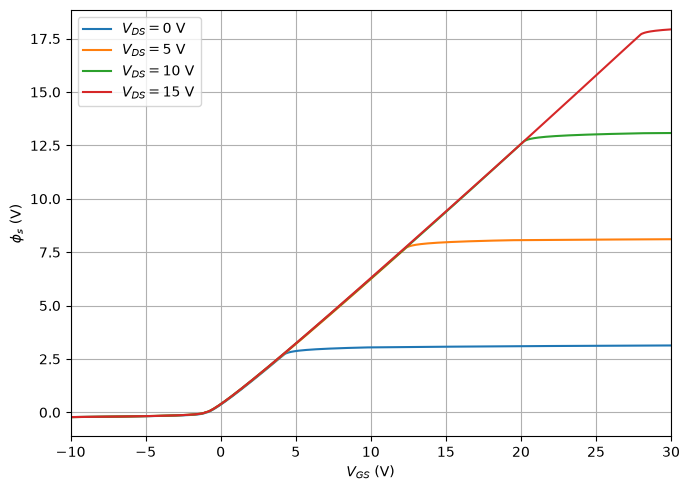

In [5]:
# Plot the trained surface potential at the training temperature.
Vgs_test = torch.linspace(
    -10.0,
    30.0,
    500,
    dtype=dtype,
    device=device,
).reshape(-1, 1)

plt.figure(
    figsize=(7, 5)
)

for VDS_VALUE in [
    0.0,
    5.0,
    10.0,
    15.0,
]:

    phi_f_test = torch.full_like(
        Vgs_test,
        VDS_VALUE,
    )

    with torch.no_grad():

        phis_test = surface_potential(
            Model,
            Vgs_test,
            phi_f_test,
            T=T,
            NA=NA,
            eps_sic=eps_sic,
            Cox=Cox,
            Vfbs0=Vfbs0,
            Dit_mid=Dit_mid,
            Dit_edge=Dit_edge,
            sigma_it=sigma_it,
            Eg=Eg,
        )

    plt.plot(
        Vgs_test.cpu(),
        phis_test.cpu(),
        label=rf"$V_{{DS}}={VDS_VALUE:.0f}$ V",
    )

plt.xlabel(
    r"$V_{GS}$ (V)"
)

plt.ylabel(
    r"$\phi_s$ (V)"
)

plt.xlim(
    -10,
    30,
)

plt.grid(
    True
)

plt.legend()

plt.tight_layout()

plt.show()